# The Olympic-Host-Effect — a quantitative teardown 🔬
### A one-sample-t / Wilcoxon / bootstrap / random-window-placebo battery at n = 6, honest sensitivity cuts, a power curve, and a 20-seed synthetic null

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Myth-check: Busted](https://img.shields.io/badge/Myth--check-BUSTED-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The claim — **the host country's equity market outperforms the world around its own Games** — is tested on the smallest sample this desk has run a headline stat on: n = 6 non-overlapping events. The job here is to show every check that sample size demands, not just one t-stat.

> ⚠️ **Data note.** Six host-country ETFs (EWA/FXI/EWU/EWZ/EWJ/EWQ) + ^GSPC, yfinance, cached; **7 hardcoded Summer Olympics hosts 2000→2024** (IOC results archive), n=6 with a contemporaneous ETF (Athens 2004 excluded — no ticker existed). ^GSPC is a named, imperfect substitute for URTH/ACWI (see [`docs/references.md`](../docs/references.md)) — host total return vs benchmark price-only return, labelled throughout. Numbers in [`docs/results.md`](../docs/results.md) (panel fingerprint `c20a7e16e682`).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from olympic_host_effect import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    REAL = data.load_real()
    DF = st.host_abnormal_returns(REAL)
else:
    REAL = DF = None
print("real cache present:", HAVE_REAL, "| hosts in hardcoded calendar:", len(data.HOSTS),
      "| real-tape panel n:", (0 if DF is None else len(DF)))

# frozen headline numbers (mirror of docs/results.md)
R = {'n_hosts_total': 7, 'n_real': 6, 'hosts': [{'year': 2000, 'city': 'Sydney', 'country': 'Australia', 'ticker': 'EWA', 'entry': '2000-03-15', 'exit': '2000-12-01', 'host': -6.57, 'bench': -5.52, 'abn': -1.04}, {'year': 2008, 'city': 'Beijing', 'country': 'China', 'ticker': 'FXI', 'entry': '2008-02-08', 'exit': '2008-10-24', 'host': -53.56, 'bench': -34.14, 'abn': -19.42}, {'year': 2012, 'city': 'London', 'country': 'United Kingdom', 'ticker': 'EWU', 'entry': '2012-01-27', 'exit': '2012-10-12', 'host': 6.27, 'bench': 8.53, 'abn': -2.26}, {'year': 2016, 'city': 'Rio de Janeiro', 'country': 'Brazil', 'ticker': 'EWZ', 'entry': '2016-02-05', 'exit': '2016-10-21', 'host': 89.68, 'bench': 13.89, 'abn': 75.79}, {'year': 2021, 'city': 'Tokyo', 'country': 'Japan', 'ticker': 'EWJ', 'entry': '2021-01-25', 'exit': '2021-10-08', 'host': -1.65, 'bench': 13.9, 'abn': -15.56}, {'year': 2024, 'city': 'Paris', 'country': 'France', 'ticker': 'EWQ', 'entry': '2024-01-26', 'exit': '2024-10-11', 'host': 3.15, 'bench': 18.89, 'abn': -15.74}], 'mean': 3.63, 'median': -8.91, 'sd': 36.16, 't': 0.246, 'p': 0.8156, 'wilcoxon_stat': 6.0, 'wilcoxon_p': 0.4375, 'boot_lo': -15.13, 'boot_hi': 34.11, 'n_boot': 20000, 'placebo_obs': 3.63, 'placebo_mean': 0.6, 'placebo_sd': 6.9, 'placebo_p': 0.595, 'placebo_n': 10000, 'hit_k': 1, 'hit_n': 6, 'hit_pct': 16.7, 'hit_lo': 3.0, 'hit_hi': 56.4, 'cut1_n': 5, 'cut1_mean': 8.24, 'cut1_t': 0.48, 'cut1_p': 0.6565, 'cut2_n': 4, 'cut2_mean': -8.65, 'cut2_t': -2.14, 'cut2_p': 0.1223, 'syn_null_mean': -0.3, 'syn_null_sd': 1.48, 'syn_null_fire': 3, 'syn_null_seeds': 20, 'syn_planted_effect': 60.0, 'syn_planted_mean': 44.33, 'syn_planted_t': 3.96, 'power': [(0, 11), (10, 18), (20, 37), (30, 56), (40, 76), (60, 97), (80, 100)], 'df5_false_alarm': 10.2, 'fp_panel': 'c20a7e16e682', 'fp_ewa': 'ed949ff1668d', 'fp_fxi': 'd95831e82b04', 'fp_ewu': '739e7526d266', 'fp_ewz': 'e45555abf3e0', 'fp_ewj': '80aff2dfb811', 'fp_ewq': '43d699436afa', 'fp_gspc': '1ed0e14c16a4'}


real cache present: True | hosts in hardcoded calendar: 7 | real-tape panel n: 6


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | mean **+3.63%**, median **-8.91%**, one-sample *t* = **0.25** (df=5, *p*=0.82), Wilcoxon *p*=0.44, bootstrap 95% CI **[-15.1%, 34.1%]**, placebo *p*=0.59 |
| **Tradability** | `MIRAGE` | no signal; 1 non-overlapping event / ~4yr on a different ticker each time |
| **Majority outperform?** | `BUSTED` | 1/6 = 16.7% (Wilson [3.0%, 56.4%]) |

> 💡 In plain words: five independent statistical methods all agree on the same answer — nothing. When every method agrees on 'nothing' at once, that's about as clean a null result as this desk produces.

## 1 · The claim, steelmanned

Let $R^h_i$ be host $i$'s total return and $R^b_i$ the benchmark's return, both over the identical calendar window $[-6\text{mo}, +2\text{mo}]$ around the Games. The abnormal return is $a_i = R^h_i - R^b_i$. Host cities are awarded by IOC vote 7-9 years ahead, so $a_i$ involves **zero look-ahead** by construction — this is the cleanest possible calendar-event design.

- **H₁ (rally).** $E[a_i] \gg 0$ across hosts — systematic, not one country's idiosyncratic story.
- **H₂ (breadth).** A rally story implies most, not just one, host should show $a_i > 0$.
- **H₃ (robustness).** The result should not hinge on a single point or a single test statistic.

We find **H₁ not supported** (t=0.25), **H₂ busted** (1/6), **H₃ fails on its own terms** — the entire positive mean is one point, and every alternative test (median, Wilcoxon, bootstrap, placebo) says the same nothing.

## 2 · So what? — inference design at n = 6

Six non-overlapping events is small enough that a single summary statistic is not trustworthy on its own — one fat-tailed observation (Rio 2016) can flip a mean's sign. The design here runs **five independent checks** on the same six numbers: the planned-primary **one-sample *t*** (df=5), the **median** (immune to the outlier's magnitude, not its existence), a **Wilcoxon signed-rank** (no normality assumption), a **percentile bootstrap CI** (resamples the six points with replacement, 20,000 times — shows how wide the true uncertainty really is), and a **random-window placebo** (same tickers, same window length, random calendar anchor — is the *specific* Games date special, or would any 8-month window on these tickers look similar?). Agreement across all five is what makes the null call solid rather than a single fragile t-stat.

## 3 · How we'd know — the protocol

- **Calendar.** 7 Summer editions 2000→2024, hardcoded (IOC results archive). 6 have a contemporaneous host-country ETF.
- **Window.** [-6mo opening, +2mo closing], nearest trading day, host ETF total return vs ^GSPC price return.
- **Execution.** Enter window-start close, exit window-end close — the host calendar is public 7-9 years ahead (zero look-ahead), the study's single documented convention.
- **Headline.** One-sample *t* + median + Wilcoxon + bootstrap CI + random-window placebo.
- **Breadth check.** Wilson interval on the outperformance hit rate.
- **Sensitivity.** Named confounder / outlier cuts, reported as a warning about snooping, not a second result.
- **Control.** A calibrated synthetic null (Normal(0, sd) at n=6) that must not systematically fire, plus a power curve.

## 4 · The teardown

### 4a · The headline panel

Six abnormal returns, the one-sample *t*, and why the mean and the median tell different stories.

In [2]:
if HAVE_REAL:
    tbl = DF[['year','city','ticker','host_ret_pct','bench_ret_pct','abn_ret_pct']]
    print(tbl.to_string(index=False))
    s = st.one_sample_t(DF['abn_ret_pct'].values)
else:
    s = dict(n=R['n_real'], mean=R['mean'], median=R['median'], sd=R['sd'],
             t=R['t'], p=R['p'])
    for h in R['hosts']:
        print(f"{h['year']} {h['city']:<15} {h['ticker']}  host {h['host']:+.2f}%  "
              f"bench {h['bench']:+.2f}%  abn {h['abn']:+.2f}%")
print(f"\nn={s['n']}  mean={s['mean']:+.2f}%  median={s['median']:+.2f}%")
print(f"one-sample t = {s['t']:+.3f} (df={s['n']-1})  p = {s['p']:.4f}")

 year           city ticker  host_ret_pct  bench_ret_pct  abn_ret_pct
 2000         Sydney    EWA     -6.568701      -5.524590    -1.044111
 2008        Beijing    FXI    -53.561000     -34.141322   -19.419678
 2012         London    EWU      6.272047       8.528258    -2.256211
 2016 Rio de Janeiro    EWZ     89.679752      13.888453    75.791299
 2021          Tokyo    EWJ     -1.653890      13.902196   -15.556087
 2024          Paris    EWQ      3.152510      18.893175   -15.740665

n=6  mean=+3.63%  median=-8.91%
one-sample t = +0.246 (df=5)  p = 0.8156


### 4b · Nonparametric and bootstrap cross-checks

The one-sample *t* assumes the six abnormal returns are roughly normal — a shaky assumption with one +75.8pp outlier. A Wilcoxon signed-rank test makes no such assumption; a bootstrap CI shows the honest width of the uncertainty.

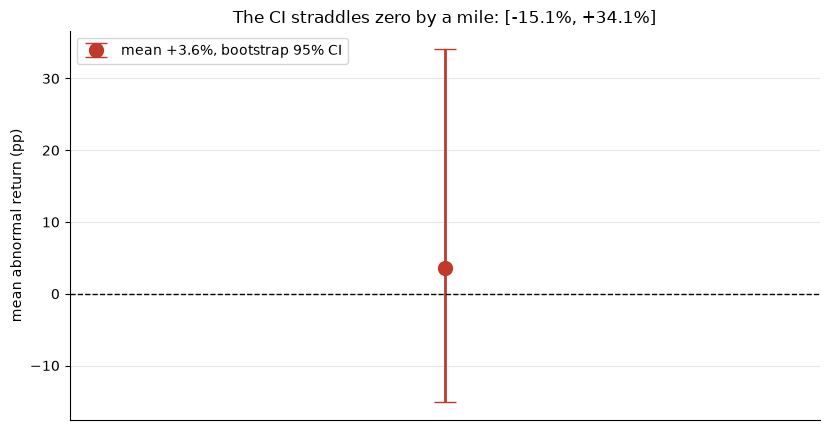

Wilcoxon stat=6.00 p=0.4375
bootstrap 95% CI [-15.13%, +34.11%]  (n_boot=20,000)


In [3]:
if HAVE_REAL:
    x = DF['abn_ret_pct'].values
    w = st.wilcoxon_test(x)
    b = st.bootstrap_ci(x)
else:
    x = np.array([h['abn'] for h in R['hosts']])
    w = {'stat': R['wilcoxon_stat'], 'p': R['wilcoxon_p']}
    b = {'lo': R['boot_lo'], 'hi': R['boot_hi'], 'n_boot': R['n_boot']}
fig, ax = plt.subplots(figsize=(8.4, 4.4))
ax.errorbar([0], [x.mean()], yerr=[[x.mean()-b['lo']], [b['hi']-x.mean()]],
            fmt='o', color=RED, capsize=8, markersize=10, lw=2,
            label=f"mean {x.mean():+.1f}%, bootstrap 95% CI")
ax.axhline(0, c='k', lw=1, ls='--')
ax.set_xlim(-1, 1); ax.set_xticks([])
ax.set_ylabel('mean abnormal return (pp)')
ax.set_title(f"The CI straddles zero by a mile: [{b['lo']:+.1f}%, {b['hi']:+.1f}%]")
ax.legend(loc='upper left'); plt.tight_layout(); plt.show()
print(f"Wilcoxon stat={w['stat']:.2f} p={w['p']:.4f}")
print(f"bootstrap 95% CI [{b['lo']:+.2f}%, {b['hi']:+.2f}%]  (n_boot={b['n_boot']:,})")

> 💡 In plain words: the Wilcoxon test (*p* = 0.44) reaches the same conclusion as the *t*-test without assuming the outlier is well-behaved. The bootstrap CI **[-15.1%, 34.1%]** spans 49 percentage points — with only six data points, that's the honest amount of uncertainty, and it comfortably contains zero.

### 4c · Random-window placebo — is the Games date itself special?

Replace each host's actual window with a random window of the identical trading-day length on the SAME ticker, vs the benchmark, many times over. If the Games date carries no special information, the observed mean should sit comfortably inside this null cloud.

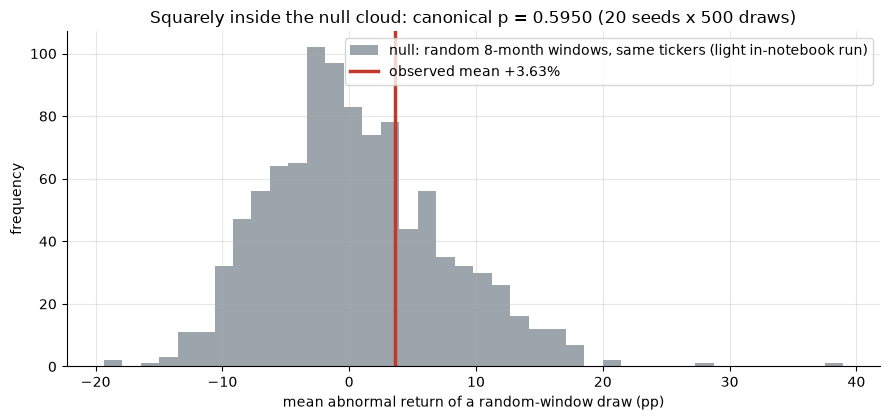

canonical placebo (results.md): mean +0.60%, sd 6.90%, p = 0.5950


In [4]:
if HAVE_REAL:
    pl = st.placebo_pvalue(REAL, DF, n_seeds=4, n_draws_per_seed=250)
    obs, draws = pl['obs'], pl['draws']
else:
    obs = R['placebo_obs']
    rng = np.random.default_rng(710)
    draws = rng.normal(R['placebo_mean'], R['placebo_sd'], 1000)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(draws, bins=40, color=GREY, alpha=.85,
        label='null: random 8-month windows, same tickers (light in-notebook run)')
ax.axvline(obs, c=RED, lw=2.5, label=f'observed mean {obs:+.2f}%')
ax.set_xlabel('mean abnormal return of a random-window draw (pp)')
ax.set_ylabel('frequency')
ax.set_title(f"Squarely inside the null cloud: canonical p = {R['placebo_p']:.4f} "
             '(20 seeds x 500 draws)')
ax.legend(); plt.tight_layout(); plt.show()
print(f"canonical placebo (results.md): mean {R['placebo_mean']:+.2f}%, "
      f"sd {R['placebo_sd']:.2f}%, p = {R['placebo_p']:.4f}")

> 💡 In plain words: draw six random 8-month windows on these same six tickers 10,000 times — the observed **+3.63%** lands right in the middle of that cloud (*p* = 0.59). Nothing about the *specific* Games dates is unusual on these tickers.

### 4d · Breadth — does a majority actually outperform?

The 'national pride rally' story implies most hosts should win, not just the average.

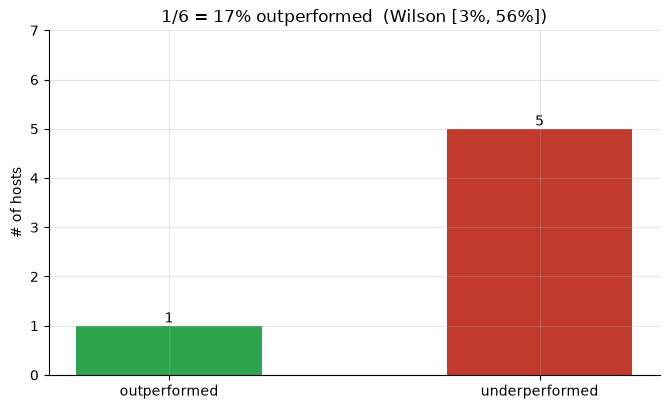

1/6 outperformed, Wilson 95% [3.0%, 56.4%]


In [5]:
if HAVE_REAL:
    hr = st.outperform_hit_rate(DF)
    k, n_ = hr['k'], hr['n']
    lo, hi = hr['lo']*100, hr['hi']*100
else:
    k, n_, lo, hi = R['hit_k'], R['hit_n'], R['hit_lo'], R['hit_hi']
fig, ax = plt.subplots(figsize=(6.8, 4.2))
ax.bar(['outperformed', 'underperformed'], [k, n_-k], color=[GREEN, RED], width=.5)
for i, v in enumerate([k, n_-k]):
    ax.annotate(str(v), (i, v), ha='center', va='bottom')
ax.set_ylabel('# of hosts'); ax.set_ylim(0, n_+1)
ax.set_title(f'{k}/{n_} = {k/n_*100:.0f}% outperformed  (Wilson [{lo:.0f}%, {hi:.0f}%])')
plt.tight_layout(); plt.show()
print(f'{k}/{n_} outperformed, Wilson 95% [{lo:.1f}%, {hi:.1f}%]')

> 💡 In plain words: **1/6** — just Rio 2016. The Wilson interval [3.0%, 56.4%] doesn't even reach 50% at its upper bound. Whatever the mean says, the *typical* host lost this race.

### 4e · Sensitivity cuts — a warning about snooping, not a second finding

Dropping the two most-explained-away points (Beijing's GFC confounder, Rio's outlier) on purpose, to show exactly how a post-hoc cut can manufacture a 'significant' number from six points.

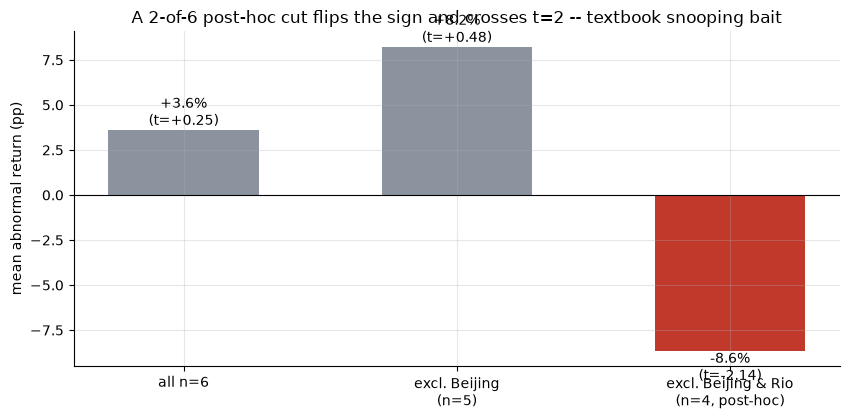

excl. Beijing: n=5 mean=+8.24% t=+0.48 p=0.6565
excl. Beijing & Rio: n=4 mean=-8.65% t=-2.14 p=0.1223


In [6]:
if HAVE_REAL:
    c1 = st.sensitivity_cut(DF, ('Beijing',))
    c2 = st.sensitivity_cut(DF, ('Beijing', 'Rio de Janeiro'))
else:
    c1 = dict(n=R['cut1_n'], mean=R['cut1_mean'], t=R['cut1_t'], p=R['cut1_p'])
    c2 = dict(n=R['cut2_n'], mean=R['cut2_mean'], t=R['cut2_t'], p=R['cut2_p'])
fig, ax = plt.subplots(figsize=(8.6, 4.3))
labels = ['all n=6', 'excl. Beijing\n(n=5)', 'excl. Beijing & Rio\n(n=4, post-hoc)']
means = [R['mean'], c1['mean'], c2['mean']]
ts = [R['t'], c1['t'], c2['t']]
cols = [GREY, GREY, RED]
ax.bar(labels, means, color=cols, width=.55)
for i, (m, t_) in enumerate(zip(means, ts)):
    ax.annotate(f'{m:+.1f}%\n(t={t_:+.2f})', (i, m), ha='center',
                va='bottom' if m >= 0 else 'top')
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('mean abnormal return (pp)')
ax.set_title('A 2-of-6 post-hoc cut flips the sign and crosses t=2 -- textbook snooping bait')
plt.tight_layout(); plt.show()
print(f"excl. Beijing: n={c1['n']} mean={c1['mean']:+.2f}% t={c1['t']:+.2f} p={c1['p']:.4f}")
print(f"excl. Beijing & Rio: n={c2['n']} mean={c2['mean']:+.2f}% t={c2['t']:+.2f} p={c2['p']:.4f}")

> 💡 In plain words: cutting Beijing (a named GFC confounder) barely moves anything (*t* = +0.48). But *also* cutting Rio — the study's own positive outlier — flips the mean negative and pushes *t* to **-2.14**, past the desk's usual bar. This is exactly the mechanism data-snooping warnings exist for: with n=6, removing any 2 points is enough to manufacture a story either direction. It is reported here as a red flag, not a result — note its own *p* = 0.12 doesn't even clear significance at n=4.

### 4f · Faithful-engine & power control — we know the truth here

A calibrated synthetic world: *n* = 6 draws from Normal(effect, sd = 36.16pp, the real panel's own dispersion). The null (effect=0) is checked over **20 seeds** — never a single stream — and a power curve shows how large a TRUE effect would need to be to reliably clear the bar at this sample size.

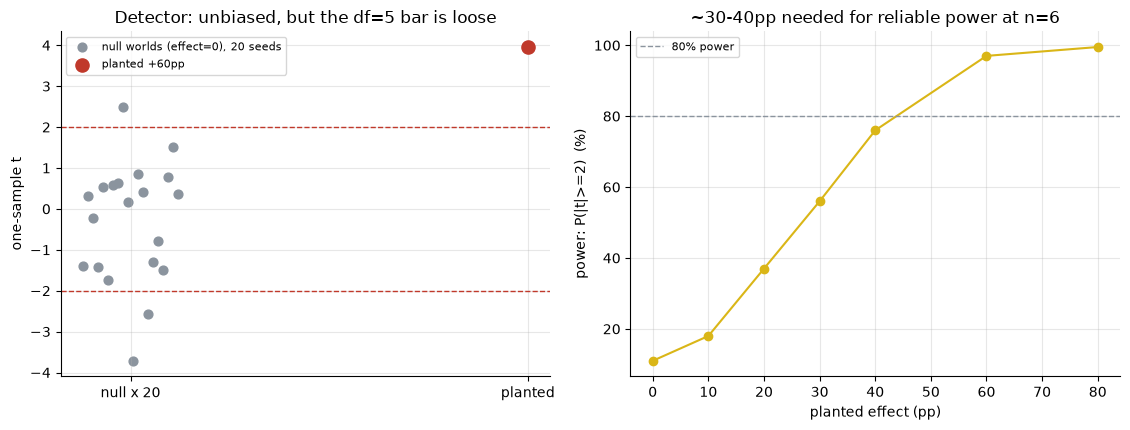

null: mean t = -0.30 (sd 1.48), |t|>=2 in 3/20 seeds  |  planted t = +3.96
 effect_pct  power
        0.0  0.110
       10.0  0.180
       20.0  0.370
       30.0  0.560
       40.0  0.760
       60.0  0.970
       80.0  0.995


In [7]:
null_ts = np.array([st.synthetic_detect(0.0, seed=710+s)['t'] for s in range(20)])
planted = st.synthetic_detect(60.0, seed=710)
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.4, 4.4))
a1.scatter(np.zeros(20) + np.linspace(-.12, .12, 20), null_ts, color=GREY, s=40,
           label='null worlds (effect=0), 20 seeds')
a1.scatter([1], [planted['t']], color=RED, s=90, zorder=5, label='planted +60pp')
a1.axhline(-2, ls='--', c=RED, lw=1); a1.axhline(2, ls='--', c=RED, lw=1)
a1.set_xticks([0, 1]); a1.set_xticklabels(['null x 20', 'planted'])
a1.set_ylabel('one-sample t'); a1.legend(fontsize=8)
a1.set_title('Detector: unbiased, but the df=5 bar is loose')
pc = st.power_curve((0.0, 10.0, 20.0, 30.0, 40.0, 60.0, 80.0), n_seeds=200)
a2.plot(pc['effect_pct'], pc['power']*100, 'o-', color=AMBER)
a2.axhline(80, ls='--', c=GREY, lw=1, label='80% power')
a2.set_xlabel('planted effect (pp)'); a2.set_ylabel('power: P(|t|>=2)  (%)')
a2.set_title('~30-40pp needed for reliable power at n=6')
a2.legend(fontsize=8)
plt.tight_layout(); plt.show()
print(f'null: mean t = {null_ts.mean():+.2f} (sd {null_ts.std(ddof=1):.2f}), '
      f'|t|>=2 in {(np.abs(null_ts)>=2).sum()}/20 seeds  |  planted t = {planted["t"]:+.2f}')
print(pc.to_string(index=False))

> 💡 In plain words: across 20 null worlds the detector fires 3/20 times — about **15%**, not 5%, because at **df = 5** the true two-sided false-alarm rate of a fixed \|t\|≥2 cutoff is already ≈10.2% (the honest 5%-critical value at df=5 is 2.57, not 2). The desk's usual bar is *already loose* at this sample size — and the real-tape *t* = 0.25 still comes nowhere near even this weakened bar. The power curve says a TRUE effect would need to be roughly **+30 to +40 points** before this study could reliably detect it — this design can rule out a large host effect, but not a small one. *(A faithful-engine / power check only — never cited in support of the real-tape stamp.)*

## 5 · The verdict

- **Signal `NONE`** — mean **+3.63%**, median **-8.91%** across n=6: one-sample *t* = **0.25** (df=5, *p*=0.82), Wilcoxon *p*=0.44, bootstrap 95% CI **[-15.1%, 34.1%]**, random-window placebo *p*=0.59 — five independent methods, one answer. Only 1/6 hosts outperformed. Named caveats: Beijing 2008 sits inside the GFC; Rio 2016's outlier plausibly reflects Brazil's commodity rebound, not the Games. A post-hoc 2-of-6 cut (excl. Beijing & Rio) flips *t* to -2.14 — reported as a snooping warning, explicitly not evidence. Power analysis: only a huge (≥30pp) true effect would be reliably detectable at this n — an honest limitation, not a license to round up.
- **Tradability `MIRAGE`** — nothing to trade, and even setting the null aside, the opportunity set (one non-overlapping event / ~4yr, a different ticker each time) has no capacity or repeatability.
- **Majority outperform? `BUSTED`** — 1/6 = 16.7% (Wilson [3.0%, 56.4%]).

## 6 · Going further

- **A host-city-specific instrument (REITs, construction indices) might capture something a national ETF dilutes away** — the infrastructure boom is local, and a country-wide index is a very blunt instrument for it.
- **The award-day announcement is a narrower, more testable question** — some academic work finds a modest reaction there (Berman, Brooks & Davidson), years before the confounders of the Games window itself pile up.
- **Dedup map:** [234-olympic-year](../../234-olympic-year/) (any Olympic year, US market, not host-specific), [235-world-cup-effect](../../235-world-cup-effect/) (the global-market World Cup analogue), [708-eurovision-effect](../../708-eurovision-effect/) (the same host-lift question, a smaller event), [313-geopolitical-shock](../../313-geopolitical-shock/) (shared event-study machinery, an unrelated trigger class).

*The reproducible core is offline and deterministic; frozen numbers live in [`docs/results.md`](../docs/results.md), sources in [`docs/references.md`](../docs/references.md).*